In [20]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib import colors
from IPython.display import display
from scipy.stats import chi2_contingency, f_oneway, ttest_ind
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import (
    RandomForestClassifier,
    RandomForestRegressor,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor

warnings.filterwarnings("ignore")

candidate_fonts = [
    "Malgun Gothic", "NanumGothic", "AppleGothic",
    "Noto Sans CJK KR", "Noto Sans KR", "DejaVu Sans",
]
available_fonts = {font.name for font in fm.fontManager.ttflist}
for font_name in candidate_fonts:
    if font_name in available_fonts:
        plt.rcParams["font.family"] = font_name
        break
plt.rcParams["axes.unicode_minus"] = False

BASE_DIR = Path.cwd()
BAT_PROCESS_PATH = BASE_DIR / "bat_process.csv"
NEW_PROCESS_PATH = BASE_DIR / "new_process.csv"

PROCESS_CONFIG = [
    {"label": "상온 에이징 1차", "row_col": "rta1_box_row", "col_col": "rta1_box_col", "dan_col": "rta1_box_dan"},
    {"label": "고온 에이징 1차", "row_col": "hta1_box_row", "col_col": "hta1_box_col", "dan_col": "hta1_box_dan"},
    {"label": "상온 에이징 2차", "row_col": "rta2_box_row", "col_col": "rta2_box_col", "dan_col": "rta2_box_dan"},
    {"label": "충전/방전", "row_col": None, "col_col": "c4_box_col", "dan_col": "c4_box_dan"},
]

STEP_CONFIG = {
    "1단계 충전": {"prefix": "c1_", "cols": ["temp_avg", "ccval", "capa", "curr_end", "voltage_avg"]},
    "1단계 방전": {"prefix": "dc1_", "cols": ["temp_avg", "capa", "capafit", "curr_end", "voltage_avg"]},
    "2단계 충전": {"prefix": "c2_", "cols": ["temp_avg", "ccval", "capa", "curr_end", "voltage_avg"]},
    "2단계 방전": {"prefix": "dc2_", "cols": ["temp_avg", "capa", "capafit", "curr_end", "voltage_avg"]},
    "3단계 충전": {"prefix": "c3_", "cols": ["temp_avg", "ccval", "cvval", "capa", "curr_end", "voltage_avg"]},
    "3단계 방전": {"prefix": "dc3_", "cols": ["temp_avg", "capa", "capafit", "curr_end", "voltage_avg"]},
    "4단계 충전": {"prefix": "c4_", "cols": ["temp_avg", "ccval", "cvval", "capa", "curr_end", "voltage_avg"]},
}

STAGE_REGRESSION_FEATURES = {
    "1단계 충전": ["c1_ccval", "c1_temp_avg", "c1_voltage_avg"],
    "1단계 방전": ["dc1_voltage_avg", "dc1_temp_avg"],
    "2단계 충전": ["c2_ccval", "c2_temp_avg", "c2_voltage_avg"],
    "2단계 방전": ["dc2_temp_avg", "dc2_voltage_avg"],
    "3단계 충전": ["c3_ccval", "c3_cvval", "c3_temp_avg", "c3_voltage_avg"],
    "3단계 방전": ["dc3_temp_avg", "dc3_voltage_avg"],
    "4단계 충전": ["c4_ccval", "c4_cvval", "c4_temp_avg", "c4_voltage_avg"],
}

NAME_MAP = {
    "temp_avg": "평균온도",
    "ccval": "정전류",
    "cvval": "정전압",
    "capa": "용량",
    "capafit": "보정용량",
    "curr_end": "종료전류",
    "voltage_avg": "평균전압",
}
            


In [21]:
def add_target_bin(df, target_col="judge"):
    out = df.copy()
    series = out[target_col]
    numeric = pd.to_numeric(series, errors="coerce")
    if numeric.notna().any():
        out = out.loc[numeric.notna()].copy()
        out["target_bin"] = numeric.loc[out.index].astype(int)
        return out

    normalized = series.astype(str).str.strip().str.lower()
    mapping = {
        "0": 0, "1": 1,
        "ok": 0, "good": 0, "양품": 0, "정상": 0,
        "ng": 1, "bad": 1, "불량": 1,
    }
    out["target_bin"] = normalized.map(mapping)
    out = out.dropna(subset=["target_bin"]).copy()
    out["target_bin"] = out["target_bin"].astype(int)
    return out


def build_ohe_pipeline(feature_cols, model):
    preprocessor = ColumnTransformer(
        [("cat", OneHotEncoder(handle_unknown="ignore"), feature_cols)]
    )
    return Pipeline([("pre", preprocessor), ("model", model)])


def aggregate_importance(pipe, feature_cols):
    encoder = pipe.named_steps["pre"].named_transformers_["cat"]
    encoded_names = encoder.get_feature_names_out(feature_cols)
    importances = pipe.named_steps["model"].feature_importances_
    imp_df = pd.DataFrame({"encoded_feature": encoded_names, "importance": importances})

    rows = []
    for col in feature_cols:
        score = imp_df.loc[
            imp_df["encoded_feature"].str.startswith(col + "_"),
            "importance",
        ].sum()
        rows.append({"변수명": col, "importance": score})

    result = pd.DataFrame(rows)
    total = result["importance"].sum()
    result["importance_pct"] = 0 if total == 0 else result["importance"] / total * 100
    result = result.sort_values("importance", ascending=False).reset_index(drop=True)
    result["rank"] = np.arange(1, len(result) + 1)
    return result


def fit_feature_rank(df, feature_cols, target, mode="clf", model_type="dt"):
    data = df[feature_cols].copy()
    data["__target__"] = target
    data = data.dropna().copy()
    if len(data) < 30 or data["__target__"].nunique() < 2:
        return pd.DataFrame(columns=["변수명", "importance", "importance_pct", "rank"])

    x_data = data[feature_cols].astype(str)
    y_data = data["__target__"]

    if mode == "clf":
        model = (
            DecisionTreeClassifier(max_depth=5, min_samples_leaf=20, random_state=42)
            if model_type == "dt"
            else RandomForestClassifier(
                n_estimators=200, max_depth=6, min_samples_leaf=10, random_state=42, n_jobs=1
            )
        )
    else:
        model = (
            DecisionTreeRegressor(max_depth=5, min_samples_leaf=20, random_state=42)
            if model_type == "dt"
            else RandomForestRegressor(
                n_estimators=200, max_depth=6, min_samples_leaf=10, random_state=42, n_jobs=1
            )
        )

    pipe = build_ohe_pipeline(feature_cols, model)
    pipe.fit(x_data, y_data)
    return aggregate_importance(pipe, feature_cols)


def significance_mark(pvalue):
    if pd.isna(pvalue):
        return "X"
    return "O" if pvalue < 0.05 else "X"


def test_defect_rate_by_axis(df, axis_col, target_col="target_bin"):
    if axis_col is None or axis_col not in df.columns:
        return np.nan
    tmp = df[[axis_col, target_col]].dropna().copy()
    if tmp[axis_col].nunique() < 2:
        return np.nan
    grouped = [group[target_col].values for _, group in tmp.groupby(axis_col)]
    grouped = [group for group in grouped if len(group) >= 2]
    if len(grouped) < 2:
        return np.nan
    try:
        return f_oneway(*grouped).pvalue
    except Exception:
        return np.nan


def test_bad_count_by_axis(df, axis_col, target_col="target_bin"):
    if axis_col is None or axis_col not in df.columns:
        return np.nan
    tmp = df[[axis_col, target_col]].dropna().copy()
    if tmp[axis_col].nunique() < 2:
        return np.nan
    table = pd.crosstab(tmp[axis_col], tmp[target_col]).reindex(columns=[0, 1], fill_value=0)
    if table.shape[0] < 2:
        return np.nan
    try:
        return chi2_contingency(table)[1]
    except Exception:
        return np.nan


def find_best_worst_3x3_blocks(rate_pivot, count_pivot, min_count=5):
    candidates = []
    rows = list(rate_pivot.index)
    cols = list(rate_pivot.columns)
    for i in range(len(rows) - 2):
        for j in range(len(cols) - 2):
            row_block = rows[i:i + 3]
            col_block = cols[j:j + 3]
            block_rates = rate_pivot.loc[row_block, col_block]
            block_counts = count_pivot.loc[row_block, col_block]
            if block_rates.isna().any().any():
                continue
            if (block_counts < min_count).any().any():
                continue
            candidates.append(
                {
                    "rows": row_block,
                    "cols": col_block,
                    "mean_bad_rate": block_rates.values.mean(),
                    "sum_count": int(block_counts.values.sum()),
                }
            )
    if not candidates:
        raise ValueError("유효한 3x3 블록을 찾지 못했습니다.")
    block_df = pd.DataFrame(candidates).sort_values("mean_bad_rate").reset_index(drop=True)
    return block_df.iloc[0].to_dict(), block_df.iloc[-1].to_dict(), block_df
            


bat_process shape: (38595, 110)
target_bin
0    37377
1     1218
Name: count, dtype: int64


,공정단계,설비위치,변수명,불량률_유의성여부,불량률_DT,불량률_RF,불량_유의성여부,불량_DT,불량_RF,DT_rank,RF_rank,평균순위,해석
0,상온 에이징 1차,열,rta1_box_col,X,1,2,X,1,2,4.0,8.0,6.0,영향 미미
1,상온 에이징 1차,연,rta1_box_row,O,3,1,O,3,1,3.0,3.0,3.0,핵심 영향 설비
2,상온 에이징 1차,단,rta1_box_dan,O,2,3,O,2,3,8.0,7.0,7.5,유의 설비
3,고온 에이징 1차,열,hta1_box_col,O,2,3,O,2,3,9.0,11.0,10.0,유의 설비
4,고온 에이징 1차,연,hta1_box_row,O,3,2,O,3,2,2.0,4.0,3.0,핵심 영향 설비
5,고온 에이징 1차,단,hta1_box_dan,O,1,1,O,1,1,7.0,6.0,6.5,유의 설비
6,상온 에이징 2차,열,rta2_box_col,O,1,2,O,1,2,10.0,10.0,10.0,유의 설비
7,상온 에이징 2차,연,rta2_box_row,O,3,1,O,3,1,5.0,2.0,3.5,유의 설비
8,상온 에이징 2차,단,rta2_box_dan,O,2,3,O,2,3,11.0,9.0,10.0,유의 설비
9,충전/방전,열,c4_box_col,O,1,1,O,1,1,1.0,1.0,1.0,핵심 영향 설비


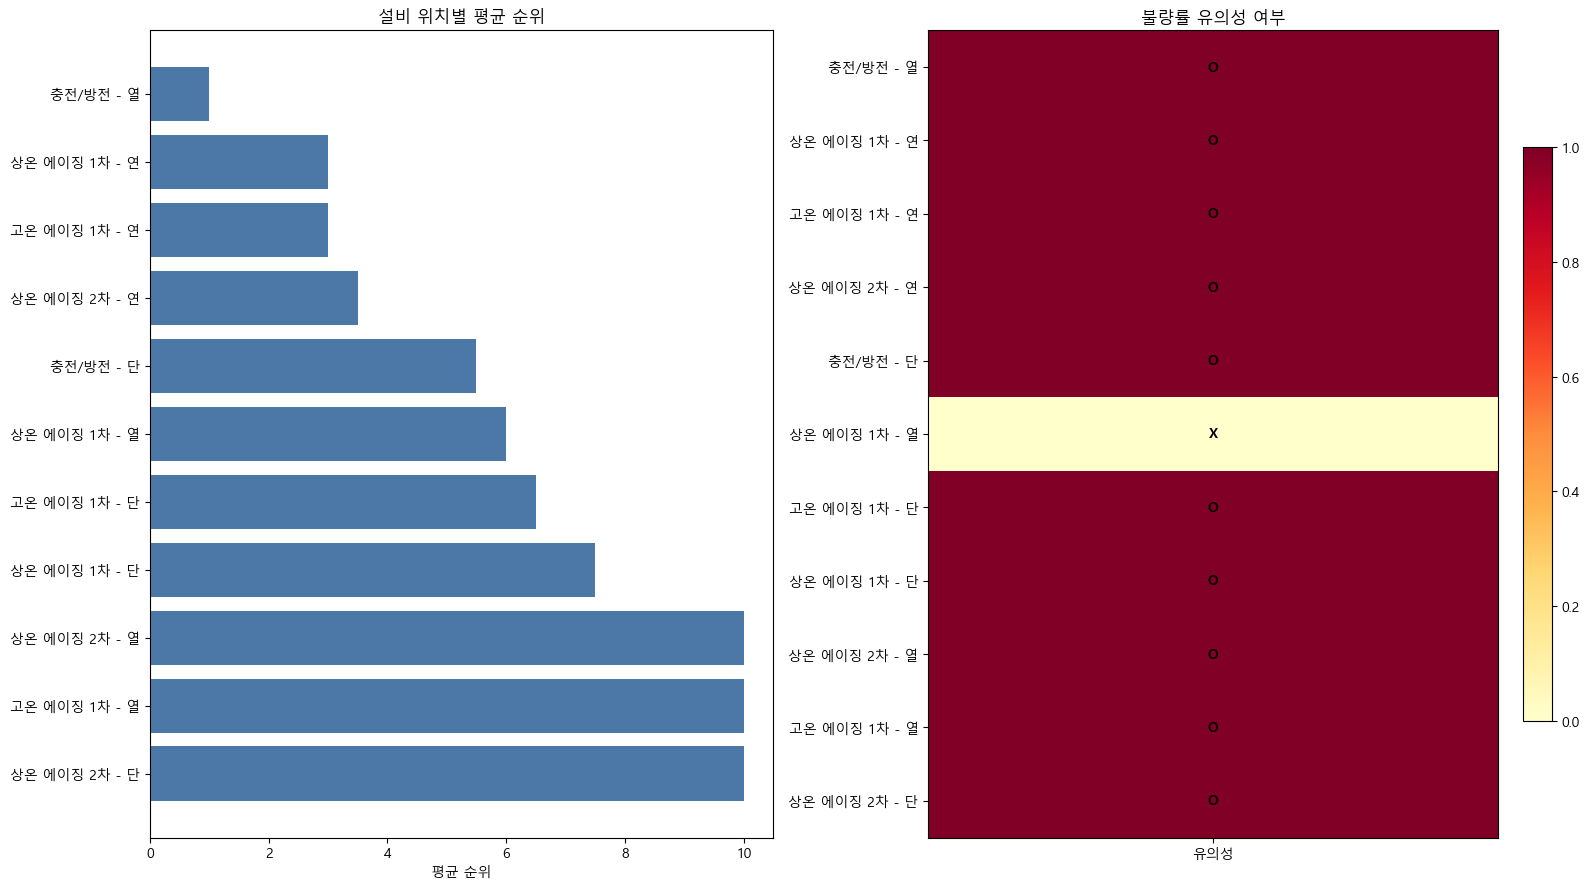

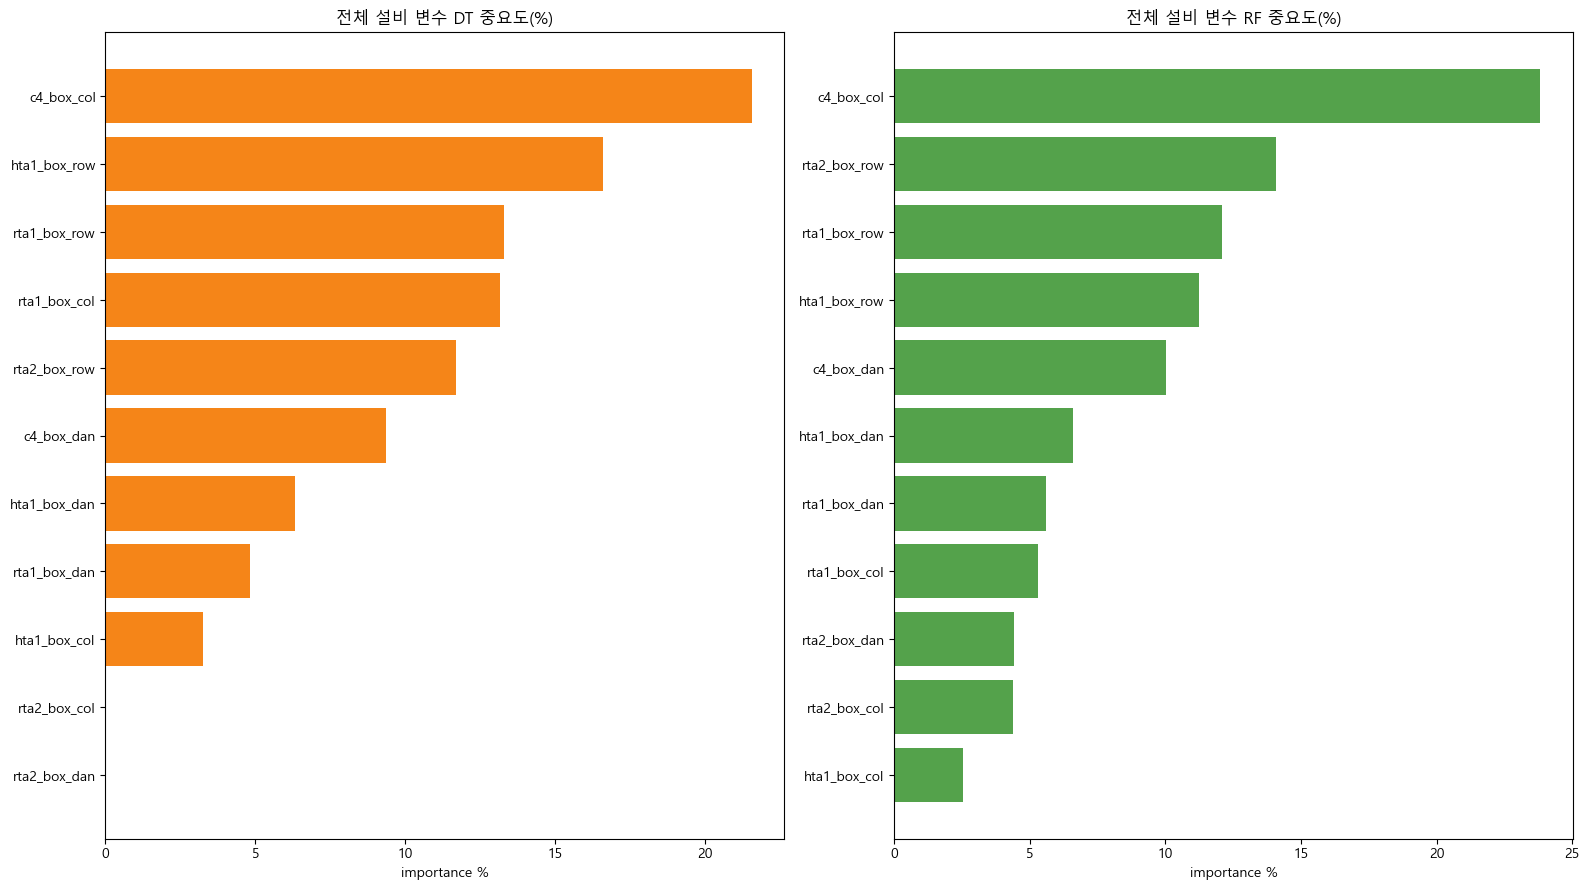

In [22]:
bat_df = add_target_bin(pd.read_csv(BAT_PROCESS_PATH, encoding="euc-kr"))
print(f"bat_process shape: {bat_df.shape}")
print(bat_df["target_bin"].value_counts().sort_index())

table_rows = []
for proc in PROCESS_CONFIG:
    axis_feature_map = {"열": proc["col_col"], "연": proc["row_col"], "단": proc["dan_col"]}
    usable_cols = [col for col in axis_feature_map.values() if col in bat_df.columns and col is not None]

    dt_rank_df = fit_feature_rank(
        bat_df.dropna(subset=usable_cols + ["target_bin"]),
        usable_cols,
        bat_df.dropna(subset=usable_cols + ["target_bin"])["target_bin"],
        mode="clf",
        model_type="dt",
    ) if usable_cols else pd.DataFrame()
    rf_rank_df = fit_feature_rank(
        bat_df.dropna(subset=usable_cols + ["target_bin"]),
        usable_cols,
        bat_df.dropna(subset=usable_cols + ["target_bin"])["target_bin"],
        mode="clf",
        model_type="rf",
    ) if usable_cols else pd.DataFrame()

    rank_map = {}
    for axis_name, col in axis_feature_map.items():
        dt_rank = dt_rank_df.loc[dt_rank_df["변수명"] == col, "rank"]
        rf_rank = rf_rank_df.loc[rf_rank_df["변수명"] == col, "rank"]
        rank_map[axis_name] = {
            "불량률_DT": int(dt_rank.iloc[0]) if len(dt_rank) else pd.NA,
            "불량률_RF": int(rf_rank.iloc[0]) if len(rf_rank) else pd.NA,
            "불량_DT": int(dt_rank.iloc[0]) if len(dt_rank) else pd.NA,
            "불량_RF": int(rf_rank.iloc[0]) if len(rf_rank) else pd.NA,
        }

    for axis_name, axis_col in axis_feature_map.items():
        table_rows.append(
            {
                "공정단계": proc["label"],
                "설비위치": axis_name,
                "변수명": axis_col,
                "불량률_유의성여부": significance_mark(test_defect_rate_by_axis(bat_df, axis_col)),
                "불량률_DT": rank_map.get(axis_name, {}).get("불량률_DT", pd.NA),
                "불량률_RF": rank_map.get(axis_name, {}).get("불량률_RF", pd.NA),
                "불량_유의성여부": significance_mark(test_bad_count_by_axis(bat_df, axis_col)),
                "불량_DT": rank_map.get(axis_name, {}).get("불량_DT", pd.NA),
                "불량_RF": rank_map.get(axis_name, {}).get("불량_RF", pd.NA),
            }
        )

result_table = pd.DataFrame(table_rows)
result_table["공정단계"] = pd.Categorical(
    result_table["공정단계"],
    categories=[proc["label"] for proc in PROCESS_CONFIG],
    ordered=True,
)
result_table["설비위치"] = pd.Categorical(result_table["설비위치"], categories=["열", "연", "단"], ordered=True)
result_table = result_table.sort_values(["공정단계", "설비위치"]).reset_index(drop=True)

all_equip_features = [row["변수명"] for _, row in result_table.iterrows() if pd.notna(row["변수명"]) and row["변수명"] in bat_df.columns]
dt_global_rank = fit_feature_rank(
    bat_df.dropna(subset=all_equip_features + ["target_bin"]),
    all_equip_features,
    bat_df.dropna(subset=all_equip_features + ["target_bin"])["target_bin"],
    mode="clf",
    model_type="dt",
)
rf_global_rank = fit_feature_rank(
    bat_df.dropna(subset=all_equip_features + ["target_bin"]),
    all_equip_features,
    bat_df.dropna(subset=all_equip_features + ["target_bin"])["target_bin"],
    mode="clf",
    model_type="rf",
)

final_equip_df = result_table.merge(
    dt_global_rank[["변수명", "rank"]].rename(columns={"rank": "DT_rank"}),
    on="변수명",
    how="left",
).merge(
    rf_global_rank[["변수명", "rank"]].rename(columns={"rank": "RF_rank"}),
    on="변수명",
    how="left",
)
final_equip_df["평균순위"] = final_equip_df[["DT_rank", "RF_rank"]].mean(axis=1)

def interpret_equip(row):
    if row["불량률_유의성여부"] == "O" and row["불량_유의성여부"] == "O":
        return "핵심 영향 설비" if row["평균순위"] <= 3 else "유의 설비"
    if row["불량률_유의성여부"] == "O" or row["불량_유의성여부"] == "O":
        return "부분 영향"
    return "영향 미미"

final_equip_df["해석"] = final_equip_df.apply(interpret_equip, axis=1)
display(final_equip_df)

plot_df = final_equip_df.dropna(subset=["평균순위"]).copy()
plot_df["설비축"] = plot_df["공정단계"].astype(str) + " - " + plot_df["설비위치"].astype(str)
plot_df = plot_df.sort_values("평균순위")

fig, axes = plt.subplots(1, 2, figsize=(16, 9))
axes[0].barh(plot_df["설비축"], plot_df["평균순위"], color="#4C78A8")
axes[0].invert_yaxis()
axes[0].set_title("설비 위치별 평균 순위")
axes[0].set_xlabel("평균 순위")

sig_numeric = plot_df["불량률_유의성여부"].map({"O": 1, "X": 0}).to_numpy().reshape(-1, 1)
im = axes[1].imshow(sig_numeric, aspect="auto", cmap="YlOrRd", vmin=0, vmax=1)
axes[1].set_title("불량률 유의성 여부")
axes[1].set_yticks(np.arange(len(plot_df)))
axes[1].set_yticklabels(plot_df["설비축"])
axes[1].set_xticks([0])
axes[1].set_xticklabels(["유의성"])
for i, value in enumerate(plot_df["불량률_유의성여부"]):
    axes[1].text(0, i, value, ha="center", va="center", fontweight="bold")
plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 9))
dt_plot = dt_global_rank.sort_values("importance")
rf_plot = rf_global_rank.sort_values("importance")
axes[0].barh(dt_plot["변수명"], dt_plot["importance_pct"], color="#F58518")
axes[0].set_title("전체 설비 변수 DT 중요도(%)")
axes[0].set_xlabel("importance %")
axes[1].barh(rf_plot["변수명"], rf_plot["importance_pct"], color="#54A24B")
axes[1].set_title("전체 설비 변수 RF 중요도(%)")
axes[1].set_xlabel("importance %")
plt.tight_layout()
plt.show()
        


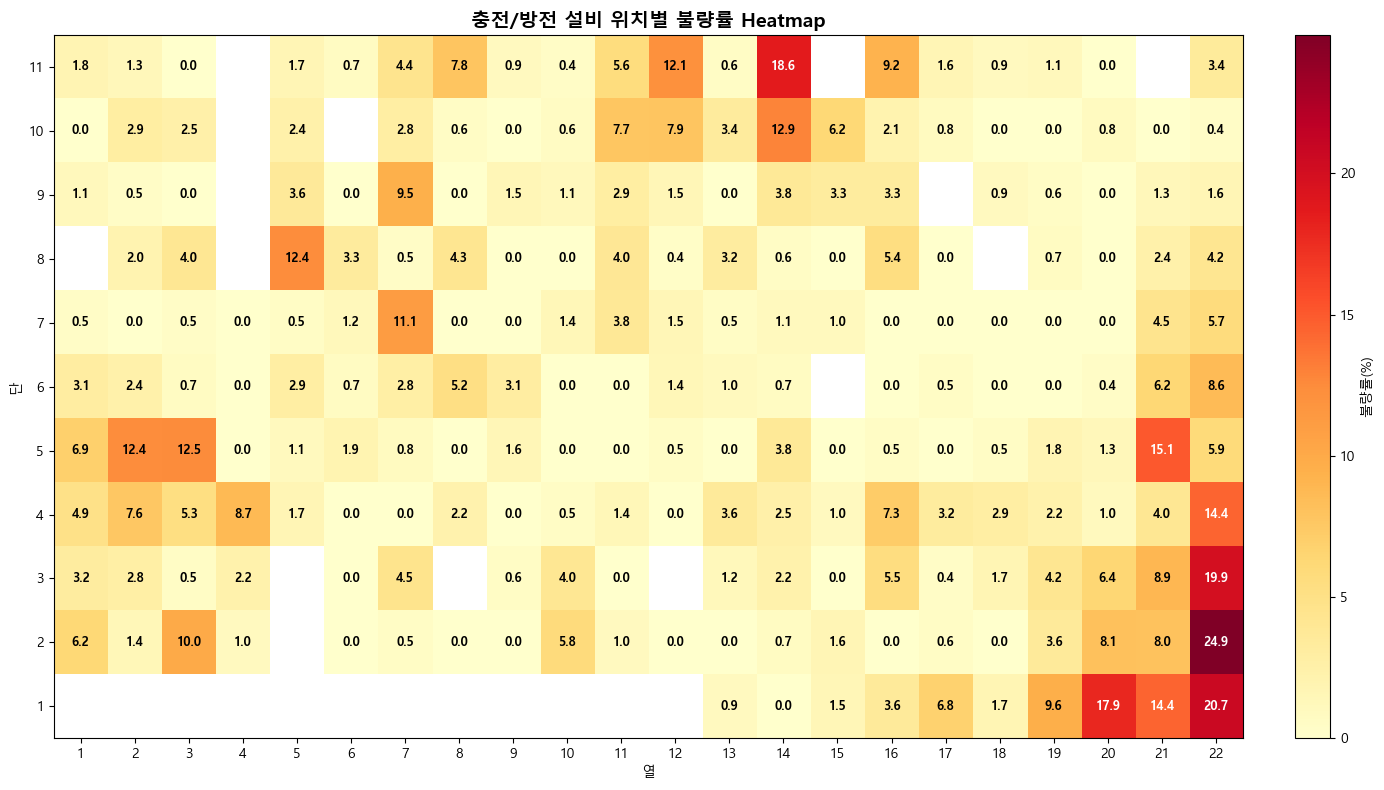

GOOD 블록: {'rows': [7, 6, 5], 'cols': [16, 17, 18], 'mean_bad_rate': 0.17271990332828574, 'sum_count': 1649}
BAD 블록: {'rows': [3, 2, 1], 'cols': [20, 21, 22], 'mean_bad_rate': 14.357809727709322, 'sum_count': 1856}
GOOD mean: 0.173
BAD mean: 14.358
t-stat: -6.2789, p-value: 0.000235


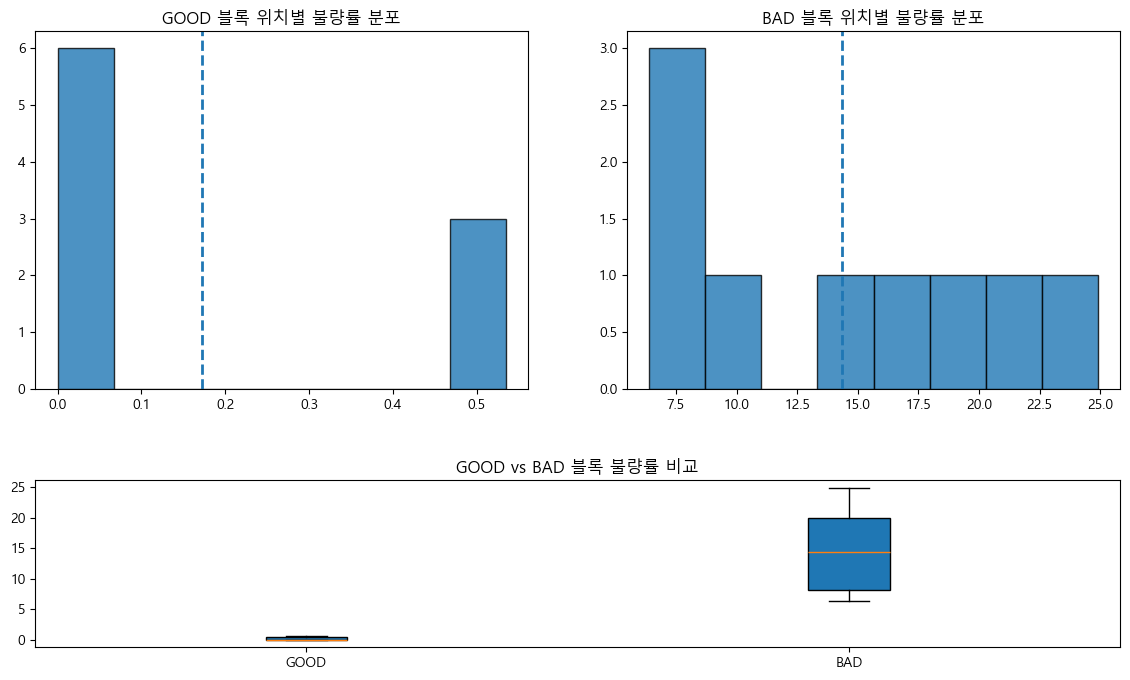

In [23]:
charge_proc = next(proc for proc in PROCESS_CONFIG if proc["label"] == "충전/방전")
heat_col = charge_proc["col_col"]
heat_dan = charge_proc["dan_col"]

heat_df = bat_df[[heat_dan, heat_col, "target_bin"]].dropna().copy()
heat_df[heat_dan] = pd.to_numeric(heat_df[heat_dan].astype(str).str.extract(r"(\d+)")[0], errors="coerce")
heat_df[heat_col] = pd.to_numeric(heat_df[heat_col].astype(str).str.extract(r"(\d+)")[0], errors="coerce")
heat_df = heat_df.dropna().copy()
heat_df[[heat_dan, heat_col]] = heat_df[[heat_dan, heat_col]].astype(int)

heat_summary = (
    heat_df.groupby([heat_dan, heat_col])["target_bin"]
    .agg(total="count", bad="sum", bad_rate="mean")
    .reset_index()
)
heat_summary["bad_rate_pct"] = heat_summary["bad_rate"] * 100

if heat_summary.empty:
    raise ValueError("충전/방전 heatmap에 사용할 유효 데이터가 없습니다.")

heatmap_pivot = heat_summary.pivot_table(index=heat_dan, columns=heat_col, values="bad_rate_pct", aggfunc="mean").sort_index(ascending=False)
count_pivot = heat_summary.pivot_table(index=heat_dan, columns=heat_col, values="total", aggfunc="sum").reindex(index=heatmap_pivot.index, columns=heatmap_pivot.columns)

fig, ax = plt.subplots(figsize=(14, 8))
cmap = plt.cm.YlOrRd
norm = colors.Normalize(vmin=np.nanmin(heatmap_pivot.values), vmax=np.nanmax(heatmap_pivot.values))
im = ax.imshow(heatmap_pivot, cmap=cmap, norm=norm, aspect="auto")
ax.set_title("충전/방전 설비 위치별 불량률 Heatmap", fontsize=14, fontweight="bold")
ax.set_xlabel("열")
ax.set_ylabel("단")
ax.set_xticks(np.arange(len(heatmap_pivot.columns)))
ax.set_xticklabels(heatmap_pivot.columns)
ax.set_yticks(np.arange(len(heatmap_pivot.index)))
ax.set_yticklabels(heatmap_pivot.index)

for i in range(heatmap_pivot.shape[0]):
    for j in range(heatmap_pivot.shape[1]):
        val = heatmap_pivot.iloc[i, j]
        if pd.notna(val):
            r, g, b, _ = cmap(norm(val))
            text_color = "white" if (0.299 * r + 0.587 * g + 0.114 * b) < 0.55 else "black"
            ax.text(j, i, f"{val:.1f}", ha="center", va="center", color=text_color, fontsize=9, fontweight="bold")

plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="불량률(%)")
plt.tight_layout()
plt.show()

best_block, worst_block, block_df = find_best_worst_3x3_blocks(heatmap_pivot, count_pivot, min_count=5)
good_df = heat_df[
    heat_df[heat_dan].isin(best_block["rows"]) &
    heat_df[heat_col].isin(best_block["cols"])
].copy()
bad_df = heat_df[
    heat_df[heat_dan].isin(worst_block["rows"]) &
    heat_df[heat_col].isin(worst_block["cols"])
].copy()

good_rate = good_df.groupby([heat_dan, heat_col])["target_bin"].mean().mul(100)
bad_rate = bad_df.groupby([heat_dan, heat_col])["target_bin"].mean().mul(100)
good_vals = good_rate.dropna()
bad_vals = bad_rate.dropna()
t_stat, p_val = ttest_ind(good_vals, bad_vals, equal_var=False)

print("GOOD 블록:", best_block)
print("BAD 블록:", worst_block)
print(f"GOOD mean: {good_vals.mean():.3f}")
print(f"BAD mean: {bad_vals.mean():.3f}")
print(f"t-stat: {t_stat:.4f}, p-value: {p_val:.6f}")

fig = plt.figure(figsize=(14, 8))
gs = fig.add_gridspec(2, 2, height_ratios=[3, 1.4], hspace=0.35, wspace=0.2)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, :])
ax1.hist(good_vals, bins=8 if good_vals.nunique() > 1 else 5, alpha=0.8, edgecolor="black")
ax1.axvline(good_vals.mean(), linestyle="--", linewidth=2)
ax1.set_title("GOOD 블록 위치별 불량률 분포")
ax2.hist(bad_vals, bins=8 if bad_vals.nunique() > 1 else 5, alpha=0.8, edgecolor="black")
ax2.axvline(bad_vals.mean(), linestyle="--", linewidth=2)
ax2.set_title("BAD 블록 위치별 불량률 분포")
ax3.boxplot([good_vals, bad_vals], labels=["GOOD", "BAD"], patch_artist=True)
ax3.set_title("GOOD vs BAD 블록 불량률 비교")
plt.tight_layout()
plt.show()
            


new_process shape: (38505, 110)
target_bin
0    37365
1     1140
Name: count, dtype: int64


,공정단계,변수명,인자,불량 여부 (t-test),DT (순위),RF (순위)
0,1단계 충전,c1_temp_avg,평균온도,O,1,1
1,1단계 충전,c1_ccval,정전류,O,5,2
2,1단계 충전,c1_capa,용량,O,4,3
3,1단계 충전,c1_voltage_avg,평균전압,O,2,4
4,1단계 충전,c1_curr_end,종료전류,X,3,5
5,1단계 방전,dc1_capafit,보정용량,O,1,1
6,1단계 방전,dc1_temp_avg,평균온도,O,2,2
7,1단계 방전,dc1_voltage_avg,평균전압,O,3,3
8,1단계 방전,dc1_curr_end,종료전류,X,4,4
9,1단계 방전,dc1_capa,용량,X,5,5


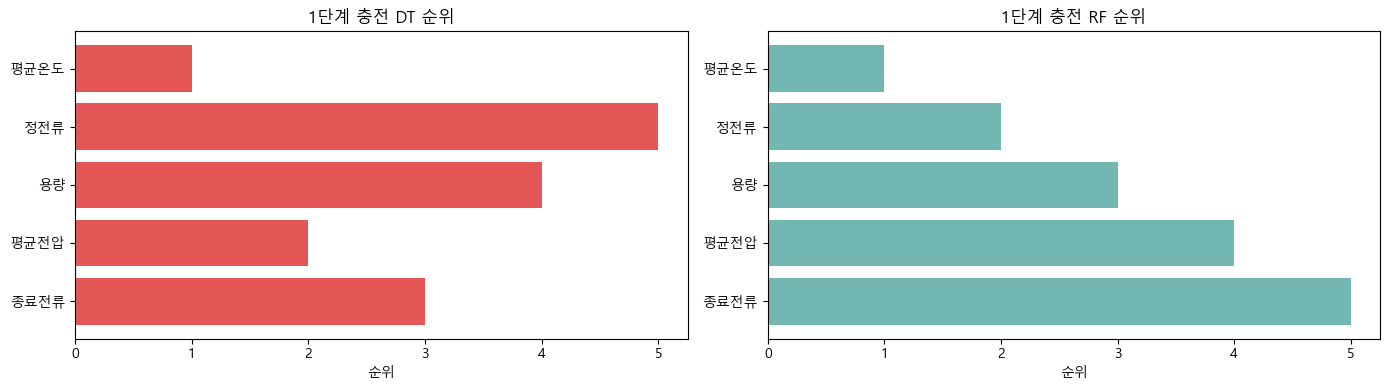

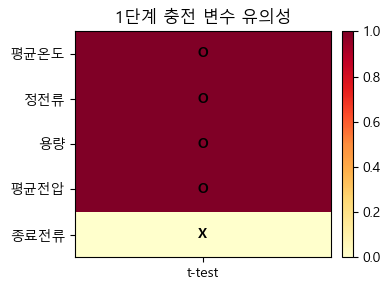

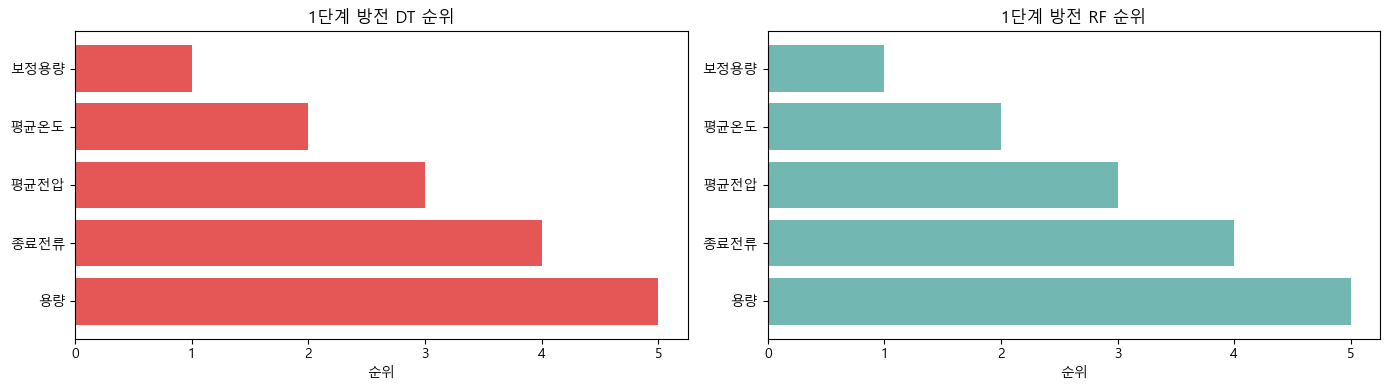

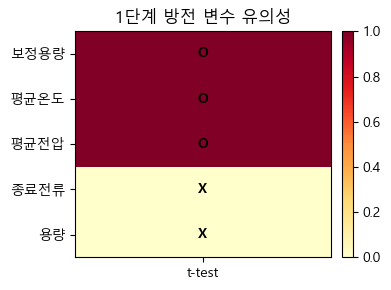

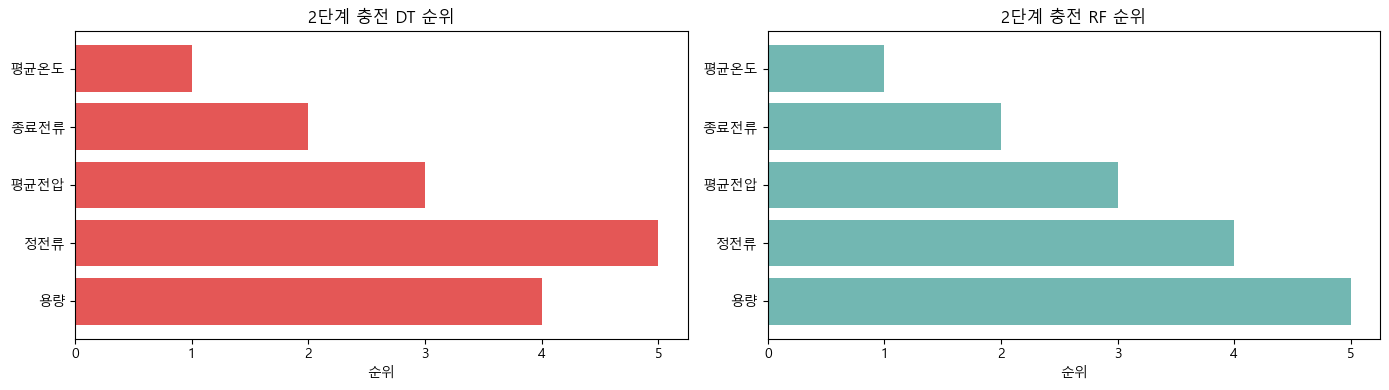

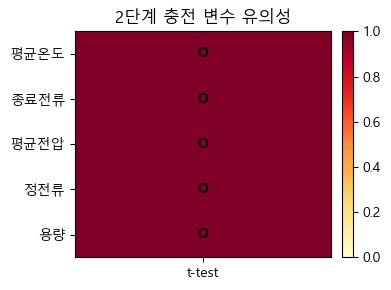

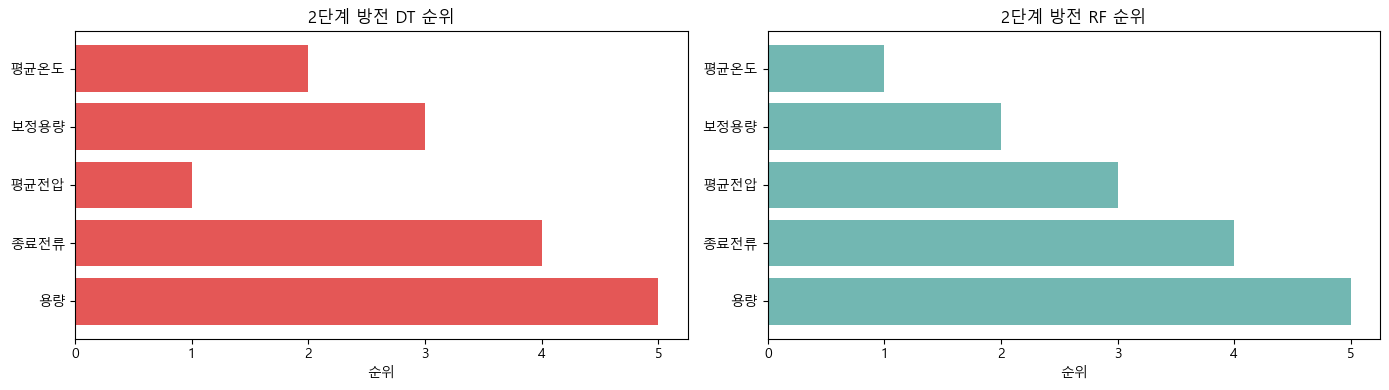

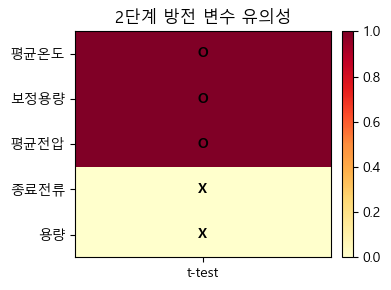

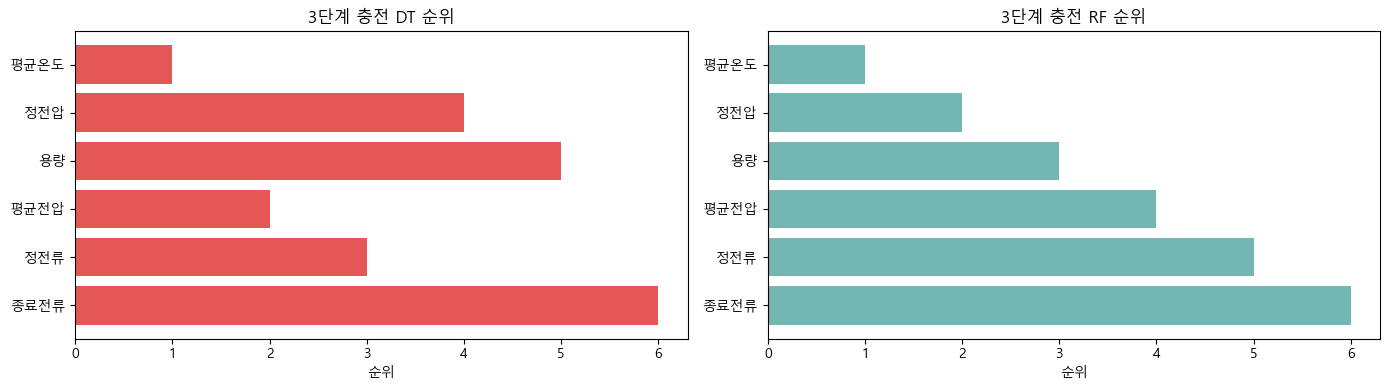

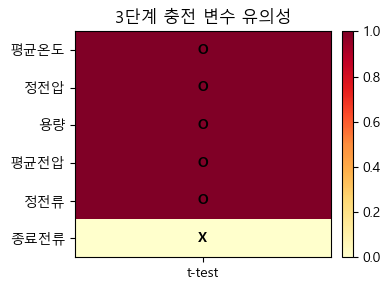

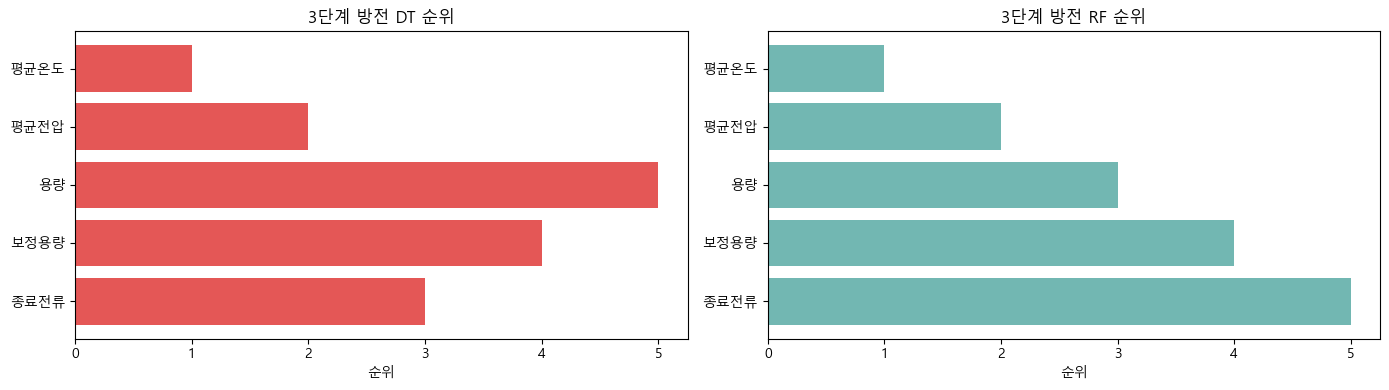

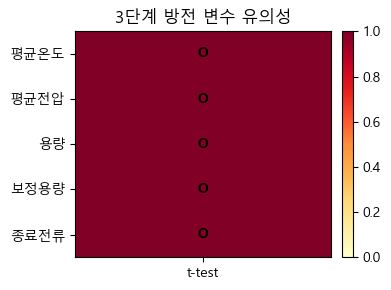

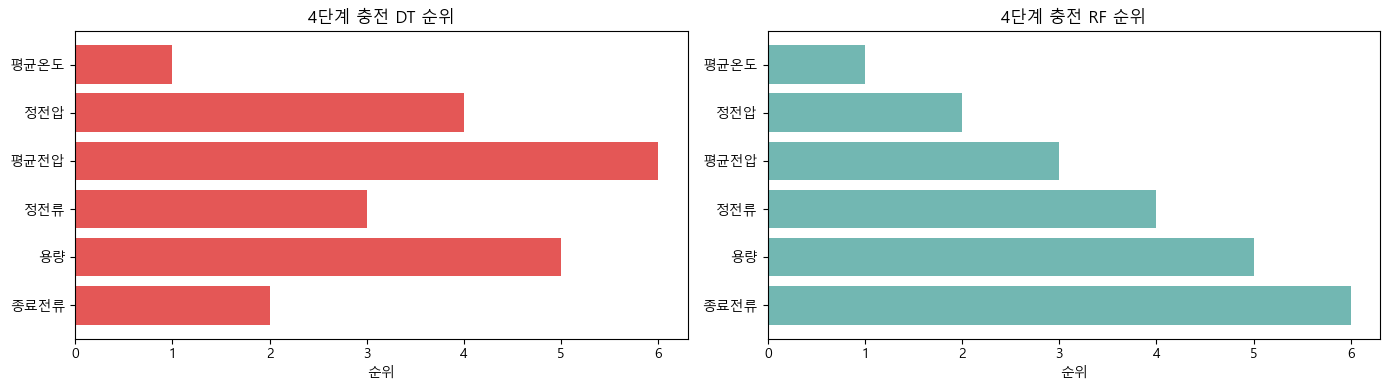

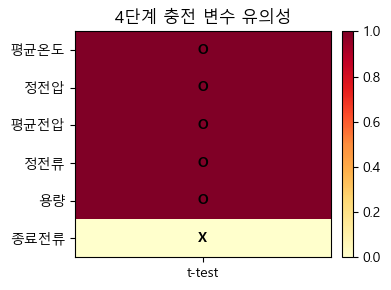

In [24]:
new_df = add_target_bin(pd.read_csv(NEW_PROCESS_PATH))
print(f"new_process shape: {new_df.shape}")
print(new_df["target_bin"].value_counts().sort_index())

step_rows = []
for step_name, config in STEP_CONFIG.items():
    valid_cols = [config["prefix"] + col for col in config["cols"] if config["prefix"] + col in new_df.columns]
    if not valid_cols:
        continue

    step_df = new_df.dropna(subset=valid_cols + ["target_bin"]).copy()
    if step_df.empty or step_df["target_bin"].nunique() < 2:
        continue

    group_0 = step_df.loc[step_df["target_bin"] == 0]
    group_1 = step_df.loc[step_df["target_bin"] == 1]
    dt_rank_df = fit_feature_rank(step_df, valid_cols, step_df["target_bin"], mode="clf", model_type="dt")
    rf_rank_df = fit_feature_rank(step_df, valid_cols, step_df["target_bin"], mode="clf", model_type="rf")

    for col in valid_cols:
        values_0 = group_0[col].dropna().values
        values_1 = group_1[col].dropna().values
        pvalue = np.nan
        if len(values_0) > 1 and len(values_1) > 1 and (np.var(values_0) > 0 or np.var(values_1) > 0):
            pvalue = ttest_ind(values_0, values_1, equal_var=False).pvalue

        suffix = col.replace(config["prefix"], "")
        step_rows.append(
            {
                "공정단계": step_name,
                "변수명": col,
                "인자": NAME_MAP.get(suffix, suffix),
                "불량 여부 (t-test)": significance_mark(pvalue),
                "DT (순위)": dt_rank_df.loc[dt_rank_df["변수명"] == col, "rank"].iloc[0] if not dt_rank_df.empty else pd.NA,
                "RF (순위)": rf_rank_df.loc[rf_rank_df["변수명"] == col, "rank"].iloc[0] if not rf_rank_df.empty else pd.NA,
            }
        )

step_result_df = pd.DataFrame(step_rows)
step_order = list(STEP_CONFIG.keys())
step_result_df["공정단계"] = pd.Categorical(step_result_df["공정단계"], categories=step_order, ordered=True)
step_result_df = step_result_df.sort_values(["공정단계", "RF (순위)", "DT (순위)", "변수명"]).reset_index(drop=True)
display(step_result_df)

for step_name in step_order:
    sub = step_result_df[step_result_df["공정단계"] == step_name].copy()
    if sub.empty:
        continue

    fig, axes = plt.subplots(1, 2, figsize=(14, max(4, len(sub) * 0.6)))
    axes[0].barh(sub["인자"], sub["DT (순위)"], color="#E45756")
    axes[0].invert_yaxis()
    axes[0].set_title(f"{step_name} DT 순위")
    axes[0].set_xlabel("순위")

    axes[1].barh(sub["인자"], sub["RF (순위)"], color="#72B7B2")
    axes[1].invert_yaxis()
    axes[1].set_title(f"{step_name} RF 순위")
    axes[1].set_xlabel("순위")
    plt.tight_layout()
    plt.show()

    sig_vals = sub["불량 여부 (t-test)"].map({"O": 1, "X": 0}).to_numpy().reshape(-1, 1)
    plt.figure(figsize=(4, max(3, len(sub) * 0.45)))
    plt.imshow(sig_vals, aspect="auto", cmap="YlOrRd", vmin=0, vmax=1)
    plt.yticks(np.arange(len(sub)), sub["인자"])
    plt.xticks([0], ["t-test"])
    for i, value in enumerate(sub["불량 여부 (t-test)"]):
        plt.text(0, i, value, ha="center", va="center", fontweight="bold")
    plt.title(f"{step_name} 변수 유의성")
    plt.colorbar(fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()
        


,count,mean,std,min,25%,50%,75%,max
c1_temp_avg,38505.0,277.273588,13.342818,239.5,268.0,277.0,287.0,315.5
dc1_temp_avg,38505.0,278.695858,13.982268,239.0,269.0,279.0,289.0,319.0
c2_temp_avg,38505.0,278.413297,13.988476,239.0,269.0,278.0,289.0,319.0
dc2_temp_avg,38505.0,278.393300,13.962306,240.5,269.0,278.0,288.0,316.5
c3_temp_avg,38505.0,277.559356,14.007287,238.0,268.0,277.0,288.0,318.0
dc3_temp_avg,38505.0,278.267290,14.275106,239.0,269.0,278.0,289.0,319.0
c4_temp_avg,38505.0,278.588391,14.966226,235.0,268.0,278.0,290.0,322.0
pg1_temp_avg,38505.0,270.340761,10.866282,242.0,262.0,271.0,277.0,298.0


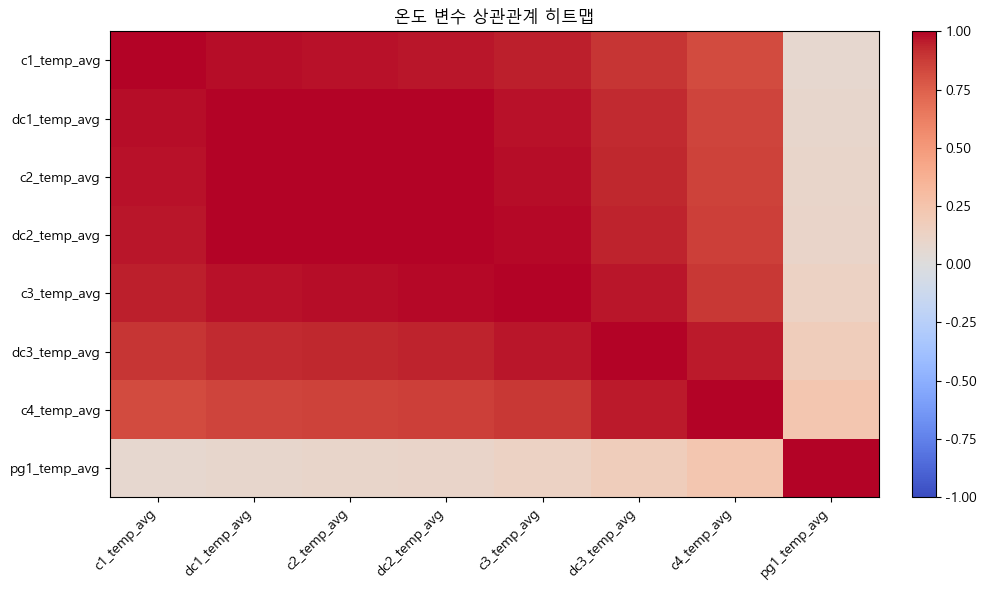

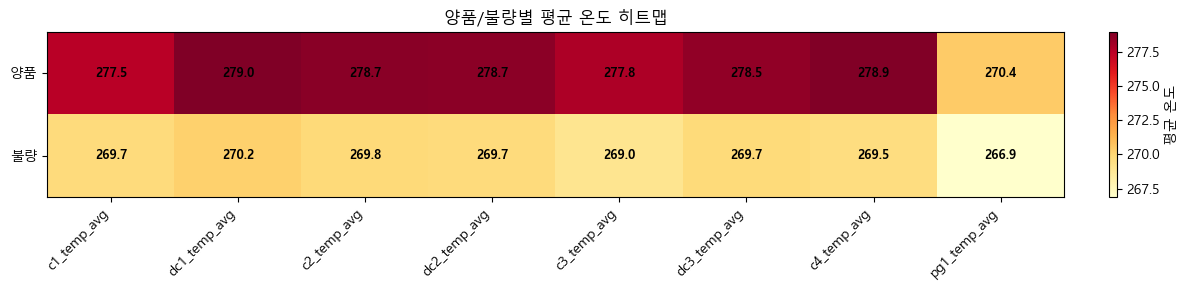

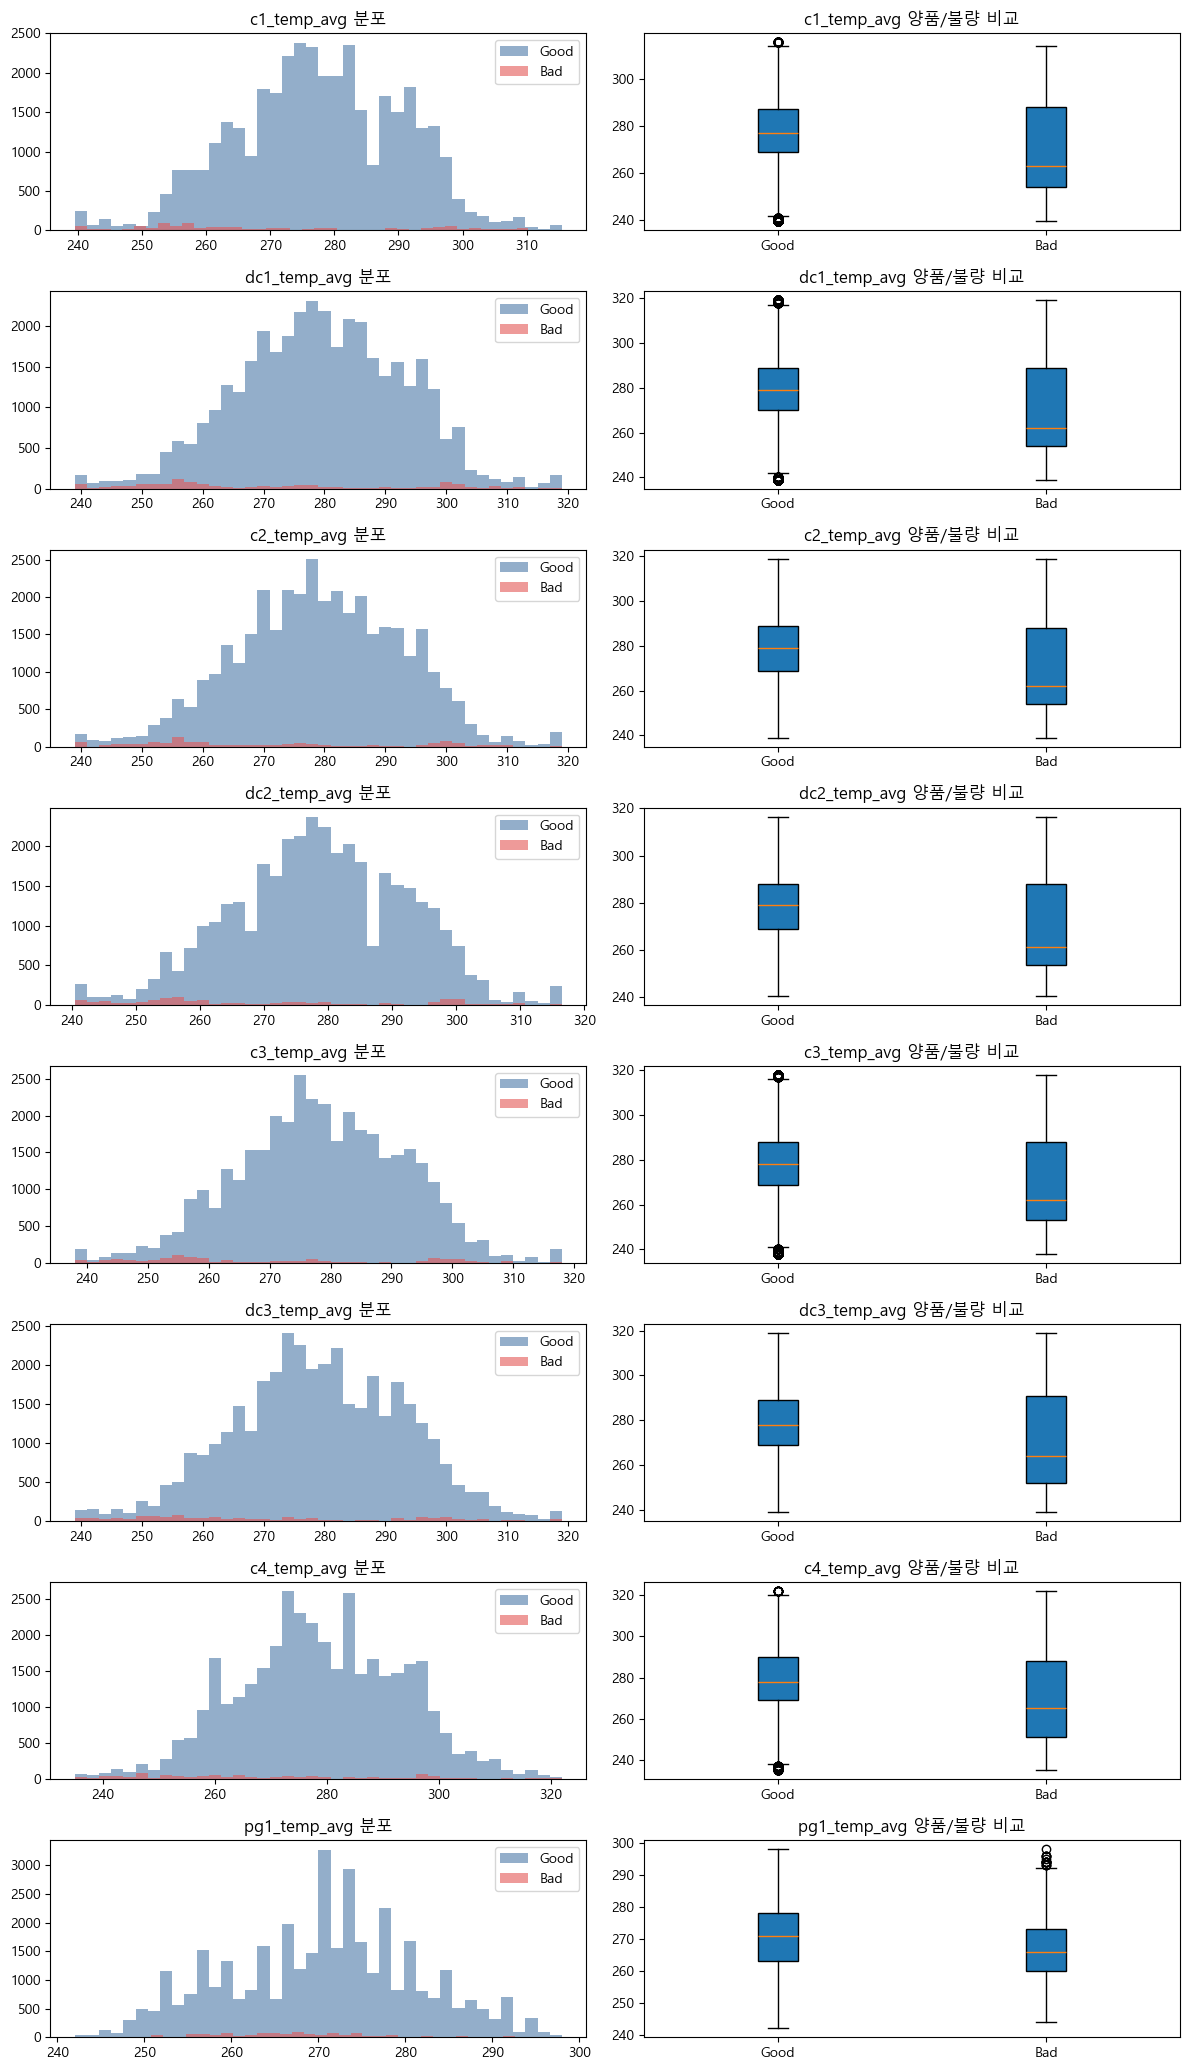

In [25]:
temp_cols = [col for col in new_df.columns if "temp_avg" in col]
temp_cols = [col for col in temp_cols if col in new_df.columns]

temp_df = new_df[temp_cols + ["target_bin"]].dropna().copy()
display(temp_df[temp_cols].describe().T)

plt.figure(figsize=(10, 6))
temp_corr = temp_df[temp_cols].corr()
plt.imshow(temp_corr, cmap="coolwarm", vmin=-1, vmax=1, aspect="auto")
plt.xticks(np.arange(len(temp_cols)), temp_cols, rotation=45, ha="right")
plt.yticks(np.arange(len(temp_cols)), temp_cols)
plt.title("온도 변수 상관관계 히트맵")
plt.colorbar(fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

temp_mean_heatmap = (
    temp_df.groupby("target_bin")[temp_cols]
    .mean()
    .rename(index={0: "양품", 1: "불량"})
)

plt.figure(figsize=(12, 3))
plt.imshow(temp_mean_heatmap, cmap="YlOrRd", aspect="auto")
plt.xticks(np.arange(len(temp_cols)), temp_cols, rotation=45, ha="right")
plt.yticks(np.arange(len(temp_mean_heatmap.index)), temp_mean_heatmap.index)
for i in range(temp_mean_heatmap.shape[0]):
    for j in range(temp_mean_heatmap.shape[1]):
        val = temp_mean_heatmap.iloc[i, j]
        plt.text(j, i, f"{val:.1f}", ha="center", va="center", fontsize=9, fontweight="bold")
plt.title("양품/불량별 평균 온도 히트맵")
plt.colorbar(fraction=0.046, pad=0.04, label="평균 온도")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(len(temp_cols), 2, figsize=(12, max(4, len(temp_cols) * 2.6)))
if len(temp_cols) == 1:
    axes = np.array([axes])

for idx, col in enumerate(temp_cols):
    good_vals = temp_df.loc[temp_df["target_bin"] == 0, col]
    bad_vals = temp_df.loc[temp_df["target_bin"] == 1, col]

    axes[idx, 0].hist(good_vals, bins=40, alpha=0.6, label="Good", color="#4C78A8")
    axes[idx, 0].hist(bad_vals, bins=40, alpha=0.6, label="Bad", color="#E45756")
    axes[idx, 0].set_title(f"{col} 분포")
    axes[idx, 0].legend()

    axes[idx, 1].boxplot([good_vals.dropna(), bad_vals.dropna()], labels=["Good", "Bad"], patch_artist=True)
    axes[idx, 1].set_title(f"{col} 양품/불량 비교")

plt.tight_layout()
plt.show()
        


,공정단계,변수명,인자,DT (순위),회귀분석(RF) (순위)
0,1단계 충전,c1_voltage_avg,평균전압,1,1
1,1단계 충전,c1_temp_avg,평균온도,2,2
2,1단계 충전,c1_ccval,정전류,3,3
3,1단계 방전,dc1_voltage_avg,평균전압,1,1
4,1단계 방전,dc1_temp_avg,평균온도,2,2
5,2단계 충전,c2_voltage_avg,평균전압,1,1
6,2단계 충전,c2_temp_avg,평균온도,2,2
7,2단계 충전,c2_ccval,정전류,3,3
8,2단계 방전,dc2_temp_avg,평균온도,1,1
9,2단계 방전,dc2_voltage_avg,평균전압,2,2


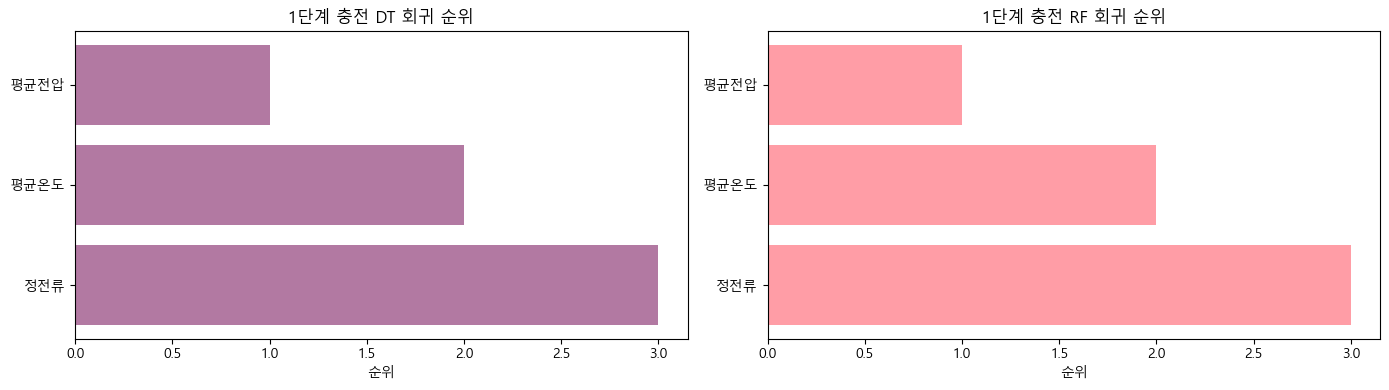

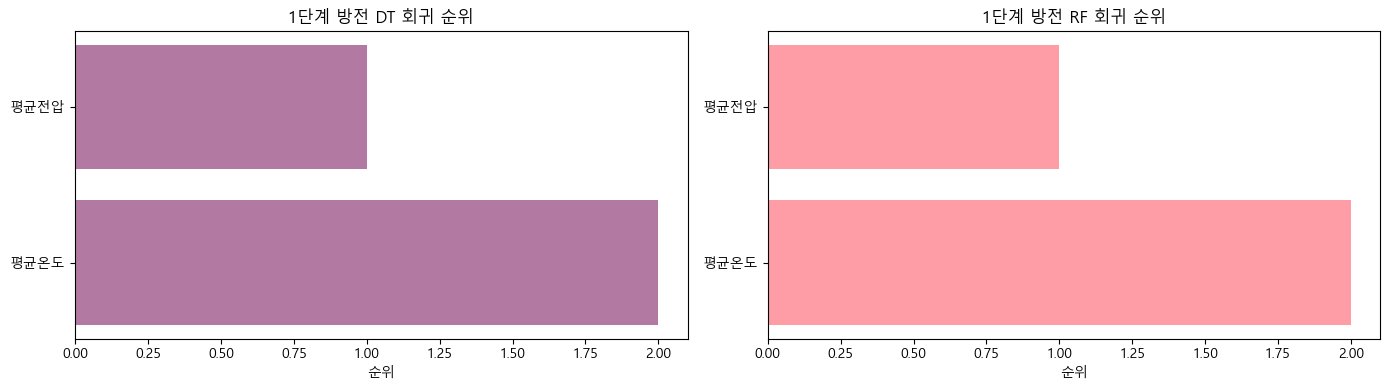

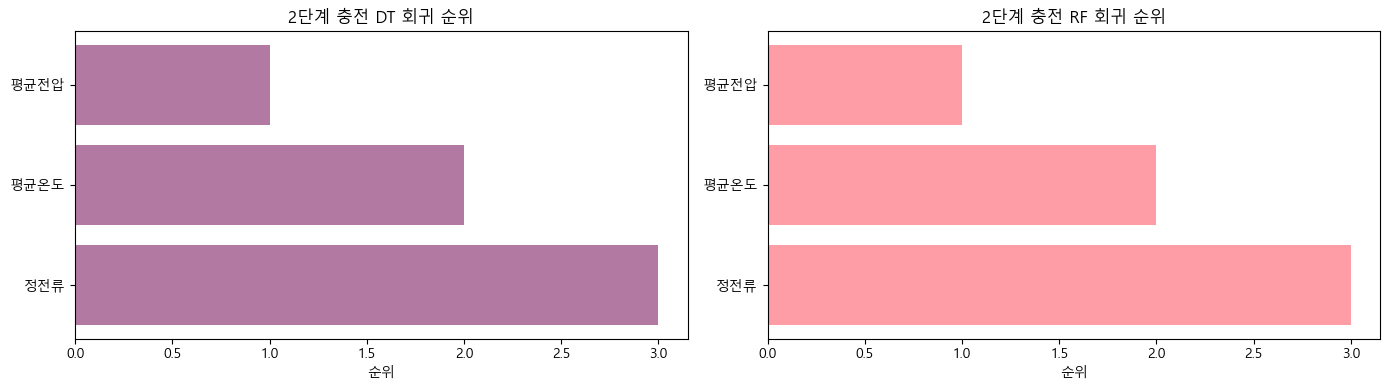

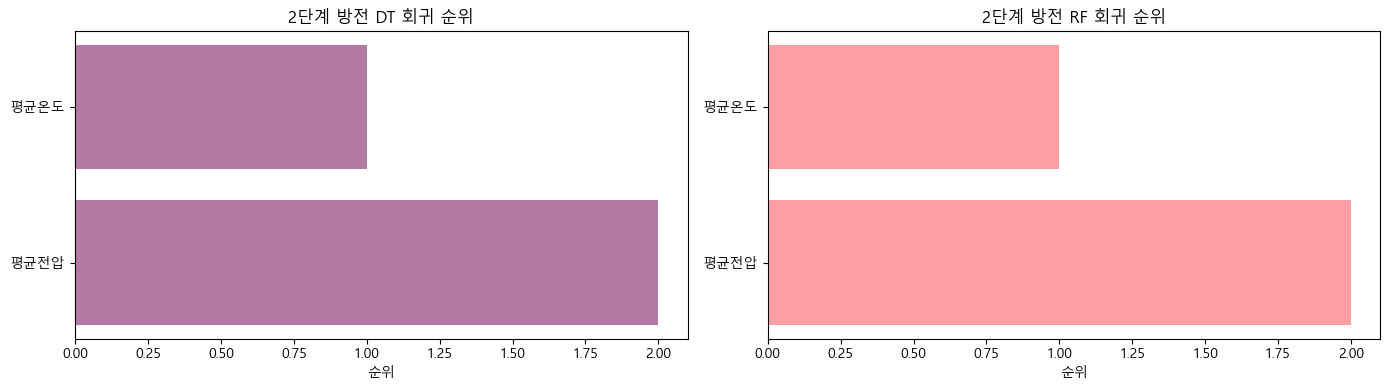

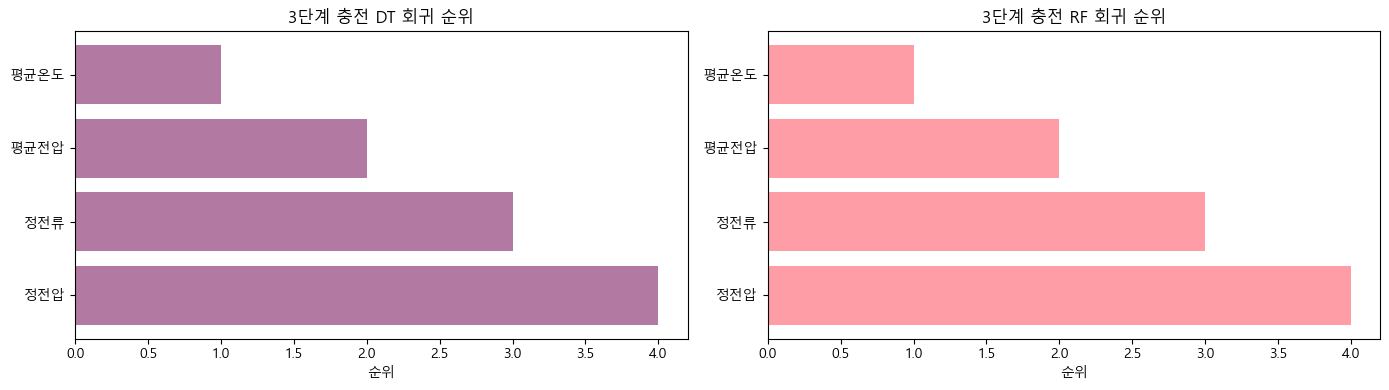

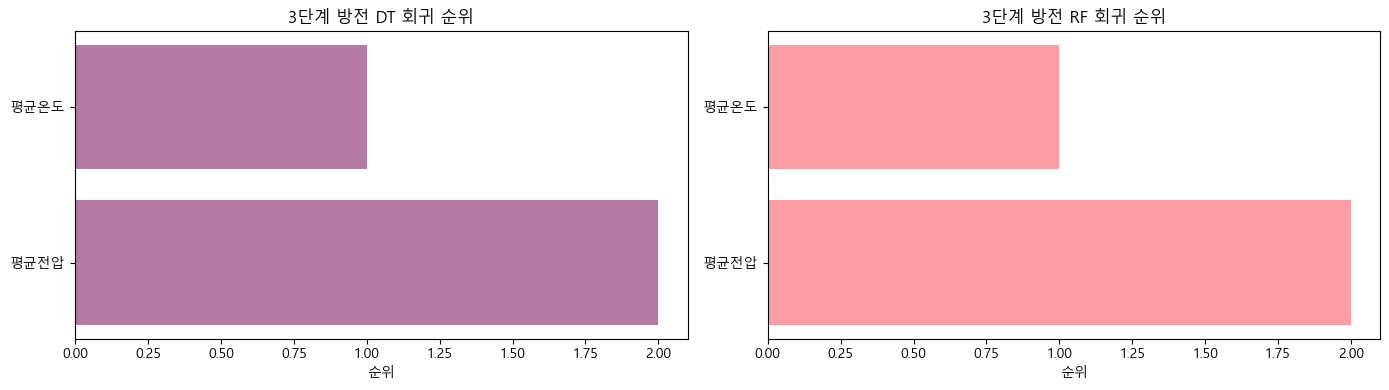

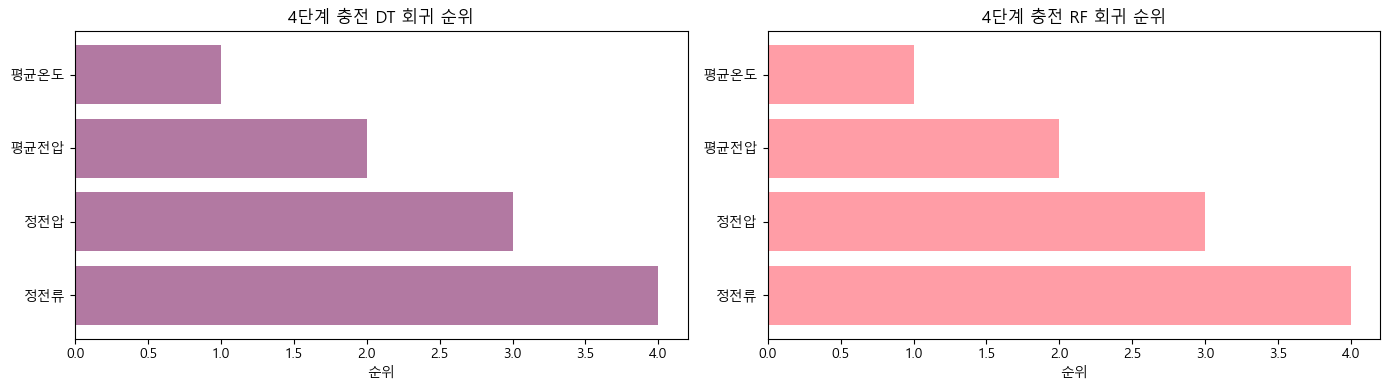

In [26]:
target_col = "pg1_impfit"
regression_rows = []

for step_name, cols in STAGE_REGRESSION_FEATURES.items():
    valid_cols = [col for col in cols if col in new_df.columns]
    if target_col not in new_df.columns or not valid_cols:
        continue

    reg_df = new_df.dropna(subset=valid_cols + [target_col]).copy()
    if len(reg_df) < 30 or reg_df[target_col].nunique() < 2:
        continue

    dt_rank_df = fit_feature_rank(reg_df, valid_cols, reg_df[target_col], mode="reg", model_type="dt")
    rf_rank_df = fit_feature_rank(reg_df, valid_cols, reg_df[target_col], mode="reg", model_type="rf")

    for col in valid_cols:
        suffix = col.split("_", 1)[1]
        regression_rows.append(
            {
                "공정단계": step_name,
                "변수명": col,
                "인자": NAME_MAP.get(suffix, suffix),
                "DT (순위)": dt_rank_df.loc[dt_rank_df["변수명"] == col, "rank"].iloc[0] if not dt_rank_df.empty else pd.NA,
                "회귀분석(RF) (순위)": rf_rank_df.loc[rf_rank_df["변수명"] == col, "rank"].iloc[0] if not rf_rank_df.empty else pd.NA,
            }
        )

regression_result_df = pd.DataFrame(regression_rows)
regression_result_df["공정단계"] = pd.Categorical(
    regression_result_df["공정단계"],
    categories=list(STAGE_REGRESSION_FEATURES.keys()),
    ordered=True,
)
regression_result_df = regression_result_df.sort_values(
    ["공정단계", "회귀분석(RF) (순위)", "DT (순위)", "변수명"]
).reset_index(drop=True)
display(regression_result_df)

for step_name in STAGE_REGRESSION_FEATURES.keys():
    sub = regression_result_df[regression_result_df["공정단계"] == step_name].copy()
    if sub.empty:
        continue

    fig, axes = plt.subplots(1, 2, figsize=(14, max(4, len(sub) * 0.6)))
    axes[0].barh(sub["인자"], sub["DT (순위)"], color="#B279A2")
    axes[0].invert_yaxis()
    axes[0].set_title(f"{step_name} DT 회귀 순위")
    axes[0].set_xlabel("순위")

    axes[1].barh(sub["인자"], sub["회귀분석(RF) (순위)"], color="#FF9DA6")
    axes[1].invert_yaxis()
    axes[1].set_title(f"{step_name} RF 회귀 순위")
    axes[1].set_xlabel("순위")
    plt.tight_layout()
    plt.show()
        


,공정단계,유의차분석(t검정),평균 불량률(%),최대 불량률(%),최소 불량률(%),ttest_pvalue
0,상온 에이징 1차,O,3.109,63.636,0.0,7.856963e-37
1,고온 에이징 1차,O,3.181,63.636,0.0,5.120534e-33
2,상온 에이징 2차,O,3.035,52.273,0.0,5.008618e-36
3,충전/방전,O,2.988,24.900,0.0,2.239453e-18


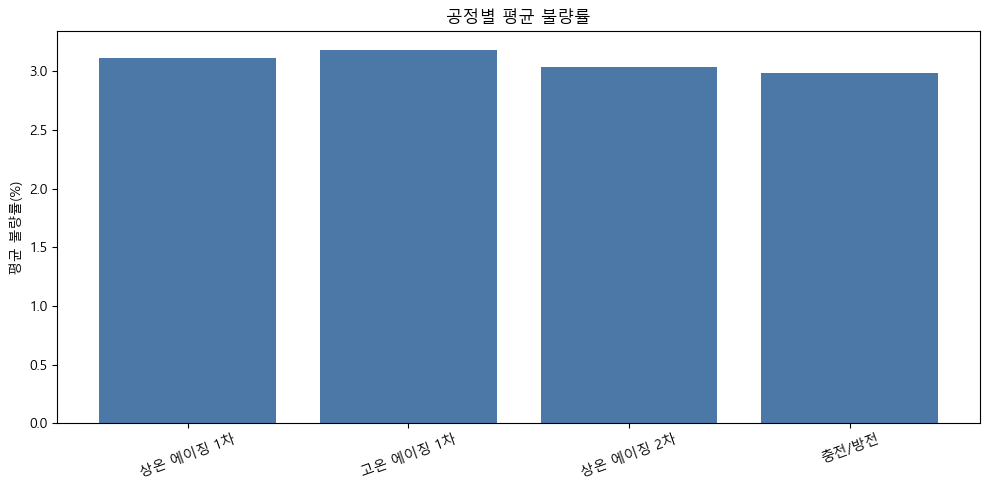

In [27]:
process_rate_rows = []
for proc in PROCESS_CONFIG:
    feature_cols = [col for col in [proc["row_col"], proc["col_col"], proc["dan_col"]] if col and col in bat_df.columns]
    tmp = bat_df[feature_cols + ["target_bin"]].dropna().copy()
    if tmp.empty:
        continue

    tmp["position_key"] = tmp[feature_cols].astype(str).agg("_".join, axis=1)
    rate_table = (
        tmp.groupby("position_key")["target_bin"]
        .agg(total="count", bad="sum", bad_rate="mean")
        .reset_index()
    )
    if len(rate_table) < 4:
        pvalue = np.nan
    else:
        q1 = rate_table["bad_rate"].quantile(0.25)
        q3 = rate_table["bad_rate"].quantile(0.75)
        low_group = rate_table.loc[rate_table["bad_rate"] <= q1, "bad_rate"]
        high_group = rate_table.loc[rate_table["bad_rate"] >= q3, "bad_rate"]
        pvalue = ttest_ind(low_group, high_group, equal_var=False).pvalue if len(low_group) > 1 and len(high_group) > 1 else np.nan

    process_rate_rows.append(
        {
            "공정단계": proc["label"],
            "유의차분석(t검정)": significance_mark(pvalue),
            "평균 불량률(%)": round(rate_table["bad_rate"].mean() * 100, 3),
            "최대 불량률(%)": round(rate_table["bad_rate"].max() * 100, 3),
            "최소 불량률(%)": round(rate_table["bad_rate"].min() * 100, 3),
            "ttest_pvalue": pvalue,
        }
    )

process_rate_df = pd.DataFrame(process_rate_rows)
display(process_rate_df)

plt.figure(figsize=(10, 5))
plt.bar(process_rate_df["공정단계"], process_rate_df["평균 불량률(%)"], color="#4C78A8")
plt.title("공정별 평균 불량률")
plt.ylabel("평균 불량률(%)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()
            


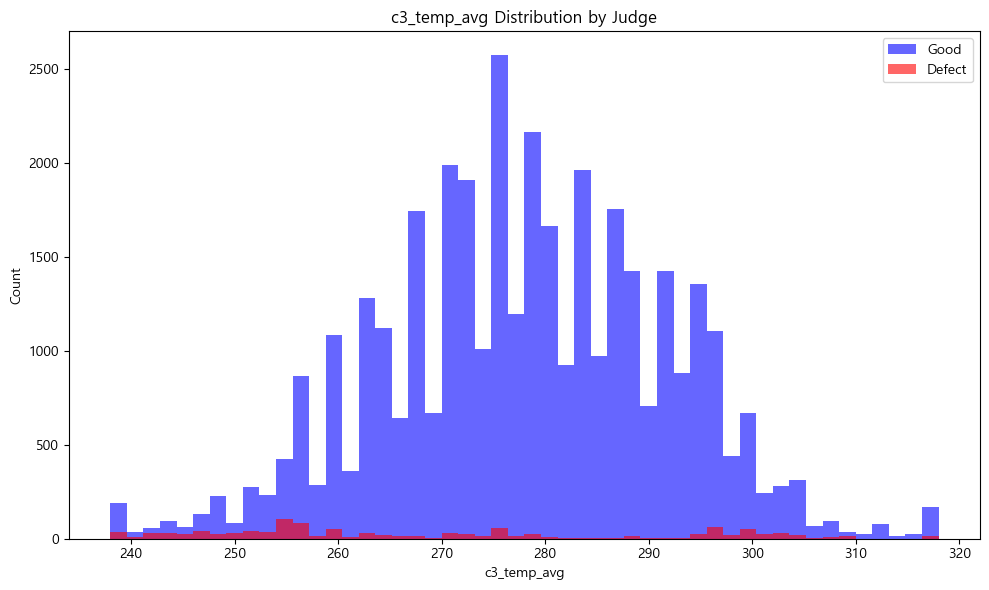

In [28]:
single_temp_df = new_df[["c3_temp_avg", "target_bin"]].dropna().copy()
good = single_temp_df.loc[single_temp_df["target_bin"] == 0, "c3_temp_avg"]
bad = single_temp_df.loc[single_temp_df["target_bin"] == 1, "c3_temp_avg"]

plt.figure(figsize=(10, 6))
plt.hist(good, bins=50, alpha=0.6, label="Good", color="blue")
plt.hist(bad, bins=50, alpha=0.6, label="Defect", color="red")
plt.xlabel("c3_temp_avg")
plt.ylabel("Count")
plt.title("c3_temp_avg Distribution by Judge")
plt.legend()
plt.tight_layout()
plt.show()
            


,변수명,t-통계량,p-value,유의성(p<0.05),DT 중요도(%),DT 순위
0,pg1_impfit,-11.6744,6.690012e-30,O,57.223748,1
2,ocv2_ocv,-7.8330,1.026725e-14,O,42.776252,2
1,ocv1_ocv,7.5548,8.079009e-14,O,0.000000,3


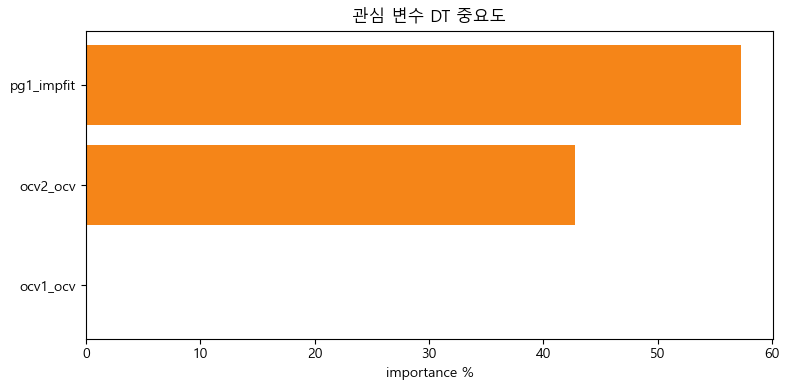

In [29]:
vars_of_interest = ["pg1_impfit", "ocv1_ocv", "ocv2_ocv"]
simple_df = new_df.dropna(subset=vars_of_interest + ["target_bin"]).copy()
group_0 = simple_df[simple_df["target_bin"] == 0]
group_1 = simple_df[simple_df["target_bin"] == 1]

simple_results = []
for var in vars_of_interest:
    t_stat, p_val = ttest_ind(group_0[var], group_1[var], equal_var=False)
    simple_results.append(
        {
            "변수명": var,
            "t-통계량": round(t_stat, 4),
            "p-value": float(p_val),
            "유의성(p<0.05)": "O" if p_val < 0.05 else "X",
        }
    )

dt_rank_df = fit_feature_rank(simple_df, vars_of_interest, simple_df["target_bin"], mode="clf", model_type="dt")
simple_summary_df = pd.DataFrame(simple_results).merge(
    dt_rank_df[["변수명", "importance_pct", "rank"]].rename(columns={"importance_pct": "DT 중요도(%)", "rank": "DT 순위"}),
    on="변수명",
    how="left",
)
display(simple_summary_df.sort_values("DT 순위"))

plt.figure(figsize=(8, 4))
plot_df = simple_summary_df.sort_values("DT 순위")
plt.barh(plot_df["변수명"], plot_df["DT 중요도(%)"], color="#F58518")
plt.gca().invert_yaxis()
plt.title("관심 변수 DT 중요도")
plt.xlabel("importance %")
plt.tight_layout()
plt.show()
            
